# Week 8

## Lecture 15 - Ensembling

A common technique used with classification methods (both non-neural and neural) is to take an ensemble of models and combine them to make classification decisions. For example, we could run 5 neural nets, each with comparable accuracy overall, and classify each datapoint based on the majority vote of the 5 networks.

(This also applies to regression problems if we do some sort of averaging of the predictions.)

Ensembling almost always improves results compared to using just one net because different nets have unique talents and may make errors on different datapoints, but, assuming all the nets have good accuracy, they are typically correct, so these mistakes are frequently restricted to just a minority of models.

Let's bring in a few modern CNN achitectures we wrote in the past to use for some ensembling. Note that any architecture would work for the forthcoming experiments.

### InceptionV3 and ResNet

First, we bring in the InceptionV3, ResNet, and the training scripts developed last week. 

In [ ]:
# ======================================================================
# run_imagefolder_experiment
#
# End-to-end PyTorch training/evaluation pipeline for image classification
# using datasets stored in ImageFolder format.
#
# Features:
#   • Loads and splits dataset into train/val/test sets with configurable ratios.
#   • Applies augmentation to training set, standard transforms to val/test.
#   • Uses tqdm progress bars for batch-level metrics during training/validation/testing.
#   • Supports AdamW or SGD optimizers, label smoothing, gradient clipping.
#   • Includes ReduceLROnPlateau scheduler (default patience=10, factor=0.5).
#   • Includes early stopping (default patience=25) on validation metric.
#   • Saves best model checkpoint based on chosen monitor ("loss" or "acc").
#   • Evaluates on held-out test set with accuracy, confusion matrix, and classification report.
#   • Plots twin-axis training curves for loss and accuracy.
#
# Arguments:
#   data_dir (str): Root folder containing subfolders for the dataset (here, we assume train and
#                   valid subsets, with class subsets below that).
#   model (nn.Module): Model architecture to train.
#   [other arguments control preprocessing, training, and hyperparameters]
#
# Returns:
#   dict: history, best test accuracy, classes, checkpoint path, device info, total train time.
# ======================================================================
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
import time
import torch
import torch.nn as nn

from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report
from torch import optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from tqdm.auto import tqdm


# ======================================================================
# Helper Functions
def split_counts(ds):
    """
    Return a Counter of class indices for either:
      - torchvision.datasets.ImageFolder
      - torch.utils.data.Subset(ImageFolder)
      - or any dataset exposing .samples or .targets; otherwise falls back to __getitem__
    """
    # If this is a Subset, unwrap to the base dataset and indices
    if isinstance(ds, torch.utils.data.Subset):
        base = ds.dataset
        idxs = ds.indices
        if hasattr(base, "samples"):
            labels = [base.samples[i][1] for i in idxs]
        elif hasattr(base, "targets"):
            labels = [base.targets[i] for i in idxs]
        else:
            # fallback (slower)
            labels = [base[i][1] for i in idxs]
    else:
        # Plain dataset (e.g., ImageFolder)
        if hasattr(ds, "samples"):
            labels = [y for _, y in ds.samples]
        elif hasattr(ds, "targets"):
            labels = list(ds.targets)
        else:
            # fallback (slower)
            labels = [ds[i][1] for i in range(len(ds))]

    return Counter(labels)

def current_lr(optim_):
    return optim_.param_groups[0]["lr"]

def accuracy_from_logits(logits, y):
    preds = logits.argmax(1)
    return (preds == y).float().mean().item()
# ======================================================================

def run_imagefolder_experiment(
    data_dir,
    model,
    *,
    img_size=224,
    resize_side=256,
    augment=True,
    normalize_stats=((0.485, 0.456, 0.406),
                     (0.229, 0.224, 0.225)),
    splits=(0.8, 0.1, 0.1),
    batch_train=32,
    batch_eval=64,
    num_workers=4,
    optimizer_name="adamw",
    lr=3e-4,
    weight_decay=5e-4,
    momentum=0.9,
    label_smoothing=0.03,
    epochs=1000,
    monitor="loss",
    min_delta=0.0,
    seed=0,
    grad_clip=None,
    patience=25,
    lr_patience=10,
    lr_factor=0.1,
    lr_min=1e-6,
    lr_cooldown=1,
    save_path="best_model.pth",
    use_aux=False,
    use_amp=False
):
    """Train/eval a model on an ImageFolder dataset.
       If `use_aux=True`, expects model to return (main_logits, aux_logits)
       and combines losses: loss = main_loss + 0.4 * aux_loss.
       If `use_amp=True`, enables mixed-precision (autocast + GradScaler) on CUDA.
    """
    # --- Device setup ---
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"[device] Using CUDA GPU: {torch.cuda.get_device_name(torch.cuda.current_device())}")
    elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        device = torch.device("mps")
        print("[device] Using Apple Metal (MPS) device")
    else:
        device = torch.device("cpu")
        print("[device] Using CPU")
    print()

    torch.manual_seed(seed)
    np.random.seed(seed)
    model = model.to(device)

    # AMP context setup (only meaningful on CUDA)
    amp_enabled = bool(use_amp and device.type == "cuda")
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)

    mean, std = normalize_stats
    if augment:
        train_tf = transforms.Compose([
            transforms.Resize(resize_side),
            transforms.RandomResizedCrop(img_size, scale=(0.7, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
    else:
        train_tf = transforms.Compose([
            transforms.Resize(resize_side),
            transforms.CenterCrop(img_size),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])

    test_tf = transforms.Compose([
        transforms.Resize(resize_side),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    # --- Dataset loading ---
    print(f"[data] Inspecting: {data_dir}")
    train_dir = os.path.join(data_dir, "train")
    valid_dir = os.path.join(data_dir, "valid")
    val_dir   = os.path.join(data_dir, "val")
    test_dir  = os.path.join(data_dir, "test")

    has_train = os.path.isdir(train_dir)
    has_valid = os.path.isdir(valid_dir) or os.path.isdir(val_dir)
    has_test  = os.path.isdir(test_dir)

    if has_train and has_valid:
        valid_root = valid_dir if os.path.isdir(valid_dir) else val_dir
        print("[data] Found explicit splits.")
        train_ds = datasets.ImageFolder(train_dir, transform=train_tf)
        val_ds   = datasets.ImageFolder(valid_root, transform=test_tf)
        test_ds  = datasets.ImageFolder(test_dir, transform=test_tf) if has_test else \
                   datasets.ImageFolder(valid_root, transform=test_tf)
        classes = train_ds.classes
    else:
        full_ds = datasets.ImageFolder(root=data_dir, transform=train_tf)
        classes = full_ds.classes
        frac_train, frac_val, frac_test = splits
        N = len(full_ds)
        n_train = int(frac_train * N)
        n_val   = int(frac_val   * N)
        n_test  = N - n_train - n_val
        train_ds, val_ds, test_ds = random_split(
            full_ds, [n_train, n_val, n_test],
            generator=torch.Generator().manual_seed(seed)
        )
        train_ds.dataset.transform = train_tf
        val_ds.dataset.transform   = test_tf
        test_ds.dataset.transform  = test_tf

    # --- Dataloaders ---
    if num_workers is None:
        num_workers = min(4, os.cpu_count() or 0)
    pin_mem = (device.type == "cuda")

    train_loader = DataLoader(train_ds, batch_size=batch_train, shuffle=True,
                              num_workers=num_workers, pin_memory=pin_mem)
    val_loader   = DataLoader(val_ds, batch_size=batch_eval, shuffle=False,
                              num_workers=num_workers, pin_memory=pin_mem)
    test_loader  = DataLoader(test_ds, batch_size=batch_eval, shuffle=False,
                              num_workers=num_workers, pin_memory=pin_mem)

    # --- Loss/optimizer/scheduler ---
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    if optimizer_name.lower() == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    else:
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    monitor_metric = monitor.lower()
    sched_mode = "min" if monitor_metric == "loss" else "max"
    scheduler = ReduceLROnPlateau(
        optimizer, mode=sched_mode, factor=lr_factor, patience=lr_patience,
        threshold=min_delta, cooldown=lr_cooldown, min_lr=lr_min, verbose=True,
    )

    best_metric = 0.0 if monitor_metric == "acc" else float("inf")
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    since_improved = 0

    # --- Training loop ---
    train_start_time = time.time()
    for epoch in range(1, epochs + 1):
        epoch_start_time = time.time()
        model.train()
        running_loss, running_correct, total = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f"[epoch {epoch:03d} | train]", leave=False)
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)

            # Forward with autocast if AMP enabled
            if amp_enabled:
                with torch.cuda.amp.autocast():
                    outputs = model(x)
                    if use_aux and isinstance(outputs, (tuple, list)) and len(outputs) == 2:
                        logits, aux_logits = outputs
                        loss = criterion(logits, y) + 0.4 * criterion(aux_logits, y)
                    else:
                        logits = outputs if not isinstance(outputs, (tuple, list)) else outputs[0]
                        loss = criterion(logits, y)
                # Backward + step via GradScaler
                scaler.scale(loss).backward()
                if grad_clip is not None:
                    scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                scaler.step(optimizer)
                scaler.update()
            else:
                # Full precision path (explicitly not using AMP)
                outputs = model(x)
                if use_aux and isinstance(outputs, (tuple, list)) and len(outputs) == 2:
                    logits, aux_logits = outputs
                    loss = criterion(logits, y) + 0.4 * criterion(aux_logits, y)
                else:
                    logits = outputs if not isinstance(outputs, (tuple, list)) else outputs[0]
                    loss = criterion(logits, y)
                loss.backward()
                if grad_clip is not None:
                    nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()

            bs = x.size(0)
            running_loss   += loss.item() * bs
            running_correct += (logits.argmax(1) == y).sum().item()
            total          += bs
            pbar.set_postfix(loss=running_loss/total, acc=running_correct/total)

        train_loss = running_loss / total
        train_acc  = running_correct / total

        # --- Validation ---
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        pbar_val = tqdm(val_loader, desc=f"[epoch {epoch:03d} | val  ]", leave=False)
        with torch.no_grad():
            # Autocast for eval only changes dtype; no GradScaler here.
            if amp_enabled:
                autocast_ctx = torch.cuda.amp.autocast()
            else:
                # Explicitly disable autocast when AMP is off
                class _NullCtx:
                    def __enter__(self): return None
                    def __exit__(self, exc_type, exc, tb): return False
                autocast_ctx = _NullCtx()

            with autocast_ctx:
                for x, y in pbar_val:
                    x, y = x.to(device), y.to(device)
                    outputs = model(x)
                    if use_aux and isinstance(outputs, (tuple, list)) and len(outputs) == 2:
                        logits, aux_logits = outputs
                        loss = criterion(logits, y) + 0.4 * criterion(aux_logits, y)
                    else:
                        logits = outputs if not isinstance(outputs, (tuple, list)) else outputs[0]
                        loss = criterion(logits, y)

                    bs = x.size(0)
                    v_loss    += loss.item() * bs
                    v_correct += (logits.argmax(1) == y).sum().item()
                    v_total   += bs
                    pbar_val.set_postfix(loss=v_loss/v_total, acc=v_correct/v_total)

        val_loss = v_loss / v_total
        val_acc  = v_correct / v_total
        history["train_loss"].append(train_loss); history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss);     history["val_acc"].append(val_acc)

        print(f"[epoch {epoch:03d}] train: loss={train_loss:.4f}, acc={train_acc:.4f} | "
              f"val: loss={val_loss:.4f}, acc={val_acc:.4f} | time: {time.time() - epoch_start_time:.2f}s")

        monitored_value = val_loss if monitor_metric == "loss" else val_acc
        scheduler.step(monitored_value)

        improved = (monitor_metric == "acc" and val_acc > best_metric + min_delta) or \
                   (monitor_metric == "loss" and val_loss < best_metric - min_delta)

        if improved:
            best_metric = val_acc if monitor_metric == "acc" else val_loss
            since_improved = 0
            torch.save(
                {"model_state": model.state_dict(),
                 "history": history,
                 "classes": classes,
                 "monitor": monitor,
                 "best_metric": best_metric},
                save_path
            )
            tqdm.write(f"  [checkpoint] New best ({monitor_metric}={best_metric:.4f}) saved -> {save_path}")
        else:
            since_improved += 1
            tqdm.write(f"  [early-stop] No improvement ({since_improved}/{patience}) "
                       f"on {monitor_metric}; best={best_metric:.4f}, current={monitored_value:.4f}")
            if since_improved >= patience:
                tqdm.write("  [early-stop] Patience exceeded — stopping.")
                break

    total_train_time = time.time() - train_start_time

    # --- Testing ---
    ckpt = torch.load(save_path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    history = ckpt["history"]
    classes = ckpt["classes"]

    model.eval()
    all_preds, all_trues = [], []
    with torch.no_grad():
        # Eval autocast (again, only dtype; no scaler)
        if amp_enabled:
            autocast_ctx = torch.cuda.amp.autocast()
        else:
            class _NullCtx:
                def __enter__(self): return None
                def __exit__(self, exc_type, exc, tb): return False
            autocast_ctx = _NullCtx()

        with autocast_ctx:
            for x, y in tqdm(test_loader, desc="[test]", leave=False):
                x = x.to(device)
                outputs = model(x)
                logits = outputs if not isinstance(outputs, (tuple, list)) else outputs[0]
                preds = logits.argmax(1).cpu().numpy()
                all_preds.append(preds)
                all_trues.append(y.numpy())

    y_true = np.concatenate(all_trues).ravel()
    y_pred = np.concatenate(all_preds).ravel()
    test_acc = (y_true == y_pred).mean()
    print(f"[eval] Test accuracy: {test_acc:.4f}")

    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(classes))))
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=classes, yticklabels=classes)
    plt.title("Confusion Matrix (Test)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    print(classification_report(y_true, y_pred, target_names=classes, digits=4))

    # --- Plot curves ---
    ep = range(1, len(history["train_loss"]) + 1)
    fig, ax1 = plt.subplots()
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss", color="tab:blue")
    ax1.plot(ep, history["train_loss"], label="Train Loss", color="tab:blue")
    ax1.plot(ep, history["val_loss"],   label="Val Loss",   color="tab:blue", linestyle="--")
    ax2 = ax1.twinx()
    ax2.set_ylabel("Accuracy", color="tab:orange")
    ax2.plot(ep, history["train_acc"], label="Train Acc", color="tab:orange")
    ax2.plot(ep, history["val_acc"],   label="Val Acc",   color="tab:orange", linestyle="--")
    ax1.legend(loc="center right")
    plt.title("Loss and Accuracy over Epochs")
    plt.show()

    return {
        "history": history,
        "test_acc": float(test_acc),
        "classes": classes,
        "checkpoint": save_path,
        "device": str(device),
        "total_train_time_sec": total_train_time,
    }


# ======================================================================
# Inception v3 — from scratch (PyTorch), for 299x299 RGB
#  - Factorized convolutions:
#      • 7x7 → (1x7) + (7x1)
#      • 3x3 → (1x3) + (3x1)
#  - BatchNorm after every conv
#  - Optional auxiliary classifier at 17x17 stage (aux_logits=True)
#  - He initialization for conv/linear, BN gamma=1, beta=0
#  - AdaptiveAvgPool → Dropout → Fully Connected (final logits)
#  - Returns (main_logits, aux_logits) during training if aux enabled; else just logits
# ======================================================================

import torch
import torch.nn as nn

# ------------------------ Conv-BN-ReLU ------------------------
class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, stride=1, padding=0):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding, bias=False)
        self.bn   = nn.BatchNorm2d(out_ch, eps=0.001)
        self.relu = nn.ReLU(inplace=True)

        nn.init.kaiming_normal_(self.conv.weight, nonlinearity='relu')
        nn.init.ones_(self.bn.weight)
        nn.init.zeros_(self.bn.bias)

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))


# ------------------------ Inception-A (35x35) ------------------------
class InceptionA(nn.Module):
    def __init__(self, in_ch, pool_proj):
        super().__init__()
        # 1x1
        self.branch1x1 = ConvBNReLU(in_ch, 64, kernel_size=1)

        # 5x5 path: 1x1 → 5x5
        self.branch5x5 = nn.Sequential(
            ConvBNReLU(in_ch, 48, kernel_size=1),
            ConvBNReLU(48, 64, kernel_size=5, padding=2)
        )

        # double 3x3: 1x1 → 3x3 → 3x3
        self.branch3x3dbl = nn.Sequential(
            ConvBNReLU(in_ch, 64, kernel_size=1),
            ConvBNReLU(64, 96, kernel_size=3, padding=1),
            ConvBNReLU(96, 96, kernel_size=3, padding=1)
        )

        # avg pool → 1x1 projection
        self.branch_pool = nn.Sequential(
            nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
            ConvBNReLU(in_ch, pool_proj, kernel_size=1)
        )

    def forward(self, x):
        b1 = self.branch1x1(x)
        b2 = self.branch5x5(x)
        b3 = self.branch3x3dbl(x)
        b4 = self.branch_pool(x)
        return torch.cat([b1, b2, b3, b4], dim=1)


# ------------------------ Inception-B (17x17) ------------------------
class InceptionB(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        # 1x1
        self.branch1x1 = ConvBNReLU(in_ch, 192, kernel_size=1)

        # 7x7 factorized: 1x1 → (1x7) → (7x1)
        self.branch7x7 = nn.Sequential(
            ConvBNReLU(in_ch, 128, kernel_size=1),
            ConvBNReLU(128, 128, kernel_size=(1,7), padding=(0,3)),
            ConvBNReLU(128, 192, kernel_size=(7,1), padding=(3,0))
        )

        # double 7x7 factorized
        self.branch7x7dbl = nn.Sequential(
            ConvBNReLU(in_ch, 128, kernel_size=1),
            ConvBNReLU(128, 128, kernel_size=(7,1), padding=(3,0)),
            ConvBNReLU(128, 128, kernel_size=(1,7), padding=(0,3)),
            ConvBNReLU(128, 128, kernel_size=(7,1), padding=(3,0)),
            ConvBNReLU(128, 192, kernel_size=(1,7), padding=(0,3))
        )

        # avg pool → 1x1
        self.branch_pool = nn.Sequential(
            nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
            ConvBNReLU(in_ch, 192, kernel_size=1)
        )

    def forward(self, x):
        b1 = self.branch1x1(x)
        b2 = self.branch7x7(x)
        b3 = self.branch7x7dbl(x)
        b4 = self.branch_pool(x)
        return torch.cat([b1, b2, b3, b4], dim=1)


# ------------------------ Inception-C (8x8) ------------------------
class InceptionC(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        # 1x1
        self.branch1x1 = ConvBNReLU(in_ch, 320, kernel_size=1)

        # 3x3 split into (1x3) and (3x1)
        self.branch3x3 = ConvBNReLU(in_ch, 384, kernel_size=1)
        self.branch3x3_1 = ConvBNReLU(384, 384, kernel_size=(1,3), padding=(0,1))
        self.branch3x3_2 = ConvBNReLU(384, 384, kernel_size=(3,1), padding=(1,0))

        # double 3x3 path then split
        self.branch3x3dbl = nn.Sequential(
            ConvBNReLU(in_ch, 448, kernel_size=1),
            ConvBNReLU(448, 384, kernel_size=3, padding=1)
        )
        self.branch3x3dbl_1 = ConvBNReLU(384, 384, kernel_size=(1,3), padding=(0,1))
        self.branch3x3dbl_2 = ConvBNReLU(384, 384, kernel_size=(3,1), padding=(1,0))

        # avg pool → 1x1
        self.branch_pool = nn.Sequential(
            nn.AvgPool2d(kernel_size=3, stride=1, padding=1),
            ConvBNReLU(in_ch, 192, kernel_size=1)
        )

    def forward(self, x):
        b1 = self.branch1x1(x)

        b2 = self.branch3x3(x)
        b2 = torch.cat([self.branch3x3_1(b2), self.branch3x3_2(b2)], dim=1)

        b3 = self.branch3x3dbl(x)
        b3 = torch.cat([self.branch3x3dbl_1(b3), self.branch3x3dbl_2(b3)], dim=1)

        b4 = self.branch_pool(x)
        return torch.cat([b1, b2, b3, b4], dim=1)


# ------------------------ Reduction-A (35→17) ------------------------
class ReductionA(nn.Module):
    # k,l,m,n are channel hyperparams used in the original paper/config
    def __init__(self, in_ch, k, l, m, n):
        super().__init__()
        self.branch3x3 = ConvBNReLU(in_ch, n, kernel_size=3, stride=2)

        self.branch3x3dbl = nn.Sequential(
            ConvBNReLU(in_ch, k, kernel_size=1),
            ConvBNReLU(k, l, kernel_size=3, padding=1),
            ConvBNReLU(l, m, kernel_size=3, stride=2)
        )

        self.branch_pool = nn.MaxPool2d(kernel_size=3, stride=2)

    def forward(self, x):
        b1 = self.branch3x3(x)
        b2 = self.branch3x3dbl(x)
        b3 = self.branch_pool(x)
        return torch.cat([b1, b2, b3], dim=1)


# ------------------------ Reduction-B (17→8) ------------------------
class ReductionB(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.branch3x3 = nn.Sequential(
            ConvBNReLU(in_ch, 192, kernel_size=1),
            ConvBNReLU(192, 320, kernel_size=3, stride=2)
        )
        self.branch7x7x3 = nn.Sequential(
            ConvBNReLU(in_ch, 192, kernel_size=1),
            ConvBNReLU(192, 192, kernel_size=(1,7), padding=(0,3)),
            ConvBNReLU(192, 192, kernel_size=(7,1), padding=(3,0)),
            ConvBNReLU(192, 192, kernel_size=3, stride=2)
        )
        self.branch_pool = nn.MaxPool2d(kernel_size=3, stride=2)

    def forward(self, x):
        b1 = self.branch3x3(x)
        b2 = self.branch7x7x3(x)
        b3 = self.branch_pool(x)
        return torch.cat([b1, b2, b3], dim=1)


# ------------------------ Auxiliary Classifier (optional) ------------------------
class InceptionAux(nn.Module):
    # Input feature map is 17x17 with 768 channels
    def __init__(self, in_ch, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.AvgPool2d(kernel_size=5, stride=3),  # 17x17 -> 5x5
            ConvBNReLU(in_ch, 128, kernel_size=1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 5 * 5, 768),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(768, num_classes)
        )
        for m in self.classifier:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


# ------------------------ Inception v3 (full) ------------------------
class InceptionV3(nn.Module):
    def __init__(self, num_classes=1000, aux_logits=True):
        super().__init__()
        self.aux_logits = aux_logits

        # Stem (299 -> 35)
        self.Conv1   = ConvBNReLU(3, 32, kernel_size=3, stride=2)        # 299 -> 149
        self.Conv2   = ConvBNReLU(32, 32, kernel_size=3)                 # 149 -> 147
        self.Conv3   = ConvBNReLU(32, 64, kernel_size=3, padding=1)      # 147 -> 147
        self.MaxPool1= nn.MaxPool2d(kernel_size=3, stride=2)             # 147 -> 73
        self.Conv4   = ConvBNReLU(64, 80, kernel_size=1)
        self.Conv5   = ConvBNReLU(80, 192, kernel_size=3)                # 73 -> 71
        self.MaxPool2= nn.MaxPool2d(kernel_size=3, stride=2)             # 71 -> 35

        # 35x35 Inception-A ×3
        self.inception_a = nn.Sequential(
            InceptionA(192, pool_proj=32),   # out: 64+64+96+32 = 256
            InceptionA(256, pool_proj=64),   # out: 64+64+96+64 = 288
            InceptionA(288, pool_proj=64)    # out: 64+64+96+64 = 288
        )

        # Reduction-A: 35 -> 17
        self.reduction_a = ReductionA(288, k=64, l=96, m=96, n=384)      # out: 384+96 + 288? (concat) = 768

        # 17x17 Inception-B ×4
        self.inception_b = nn.Sequential(
            InceptionB(768),
            InceptionB(768),
            InceptionB(768),
            InceptionB(768)
        )

        # Optional auxiliary classifier at 17x17 stage
        if aux_logits:
            self.aux = InceptionAux(768, num_classes)

        # Reduction-B: 17 -> 8
        self.reduction_b = ReductionB(768)                                # out: 320 + 192 + 768? (pooled) = 1280

        # 8x8 Inception-C ×3
        self.inception_c = nn.Sequential(
            InceptionC(1280),
            InceptionC(2048),
            InceptionC(2048)
        )

        # Head
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.5)
        self.fc      = nn.Linear(2048, num_classes)
        nn.init.kaiming_normal_(self.fc.weight, nonlinearity='relu')
        nn.init.zeros_(self.fc.bias)

    def forward(self, x):
        # Stem
        x = self.Conv1(x);  x = self.Conv2(x);  x = self.Conv3(x)
        x = self.MaxPool1(x)
        x = self.Conv4(x);  x = self.Conv5(x)
        x = self.MaxPool2(x)

        # 35x35 → Inception-A stack → Reduction-A
        x = self.inception_a(x)
        x = self.reduction_a(x)

        # 17x17 → Inception-B stack (+ aux during training)
        x = self.inception_b(x)
        aux_out = None
        if self.aux_logits and self.training:
            aux_out = self.aux(x)

        # 8x8 → Reduction-B → Inception-C stack
        x = self.reduction_b(x)
        x = self.inception_c(x)

        # Classifier
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)

        if self.aux_logits and self.training:
            return x, aux_out
        return x

# ======================================================================
# ResNet (ImageNet-style, 224x224 RGB)
#  - BasicBlock (expansion=1) for ResNet-18/34
#  - Bottleneck (expansion=4) for ResNet-50/101/152
#  - Post-activation design (conv → BN → ReLU)
#  - He (Kaiming) initialization for conv/linear
#  - Optional zero_init_residual to start residual branches near identity
#  - num_classes: output logits dimension
# ======================================================================
import torch
import torch.nn as nn


# ===================== 1) Building blocks =====================
def conv3x3(in_planes, out_planes, stride=1, groups=1, dilation=1):
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=dilation, groups=groups, bias=False, dilation=dilation)

def conv1x1(in_planes, out_planes, stride=1):
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)


class BasicBlock(nn.Module):
    """ResNet-18/34 block."""
    expansion = 1
    def __init__(self, inplanes, planes, stride=1, downsample=None,
                 groups=1, base_width=64, dilation=1, norm_layer=None):
        super().__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        if groups != 1 or base_width != 64:
            raise ValueError("BasicBlock only supports groups=1 and base_width=64.")
        if dilation > 1:
            raise NotImplementedError("Dilation > 1 not supported in BasicBlock.")

        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1   = norm_layer(planes)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2   = norm_layer(planes)
        self.downsample = downsample
        self.stride = stride

        # Init
        nn.init.kaiming_normal_(self.conv1.weight, nonlinearity="relu")
        nn.init.kaiming_normal_(self.conv2.weight, nonlinearity="relu")
        nn.init.ones_(self.bn1.weight); nn.init.zeros_(self.bn1.bias)
        nn.init.ones_(self.bn2.weight); nn.init.zeros_(self.bn2.bias)

    def forward(self, x):
        identity = x

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        if self.downsample is not None:
            identity = self.downsample(x)

        out = self.relu(out + identity)
        return out


class Bottleneck(nn.Module):
    """ResNet-50/101/152 block."""
    expansion = 4
    def __init__(self, inplanes, planes, stride=1, downsample=None,
                 groups=1, base_width=64, dilation=1, norm_layer=None):
        super().__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        width = int(planes * (base_width / 64.)) * groups

        self.conv1 = conv1x1(inplanes, width)
        self.bn1   = norm_layer(width)

        self.conv2 = nn.Conv2d(width, width, kernel_size=3, stride=stride,
                               padding=dilation, groups=groups, bias=False, dilation=dilation)
        self.bn2   = norm_layer(width)

        self.conv3 = conv1x1(width, planes * self.expansion)
        self.bn3   = norm_layer(planes * self.expansion)

        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

        # Init
        nn.init.kaiming_normal_(self.conv1.weight, nonlinearity="relu")
        nn.init.kaiming_normal_(self.conv2.weight, nonlinearity="relu")
        nn.init.kaiming_normal_(self.conv3.weight, nonlinearity="relu")
        nn.init.ones_(self.bn1.weight); nn.init.zeros_(self.bn1.bias)
        nn.init.ones_(self.bn2.weight); nn.init.zeros_(self.bn2.bias)
        nn.init.ones_(self.bn3.weight); nn.init.zeros_(self.bn3.bias)

    def forward(self, x):
        identity = x

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))

        if self.downsample is not None:
            identity = self.downsample(x)

        out = self.relu(out + identity)
        return out


# ===================== 2) ResNet backbone =====================
class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=1000,
                 zero_init_residual=False,
                 groups=1, width_per_group=64,
                 replace_stride_with_dilation=None,
                 norm_layer=None, in_channels=3):
        """
        block: BasicBlock or Bottleneck
        layers: list with number of blocks per stage, e.g. [2,2,2,2] for ResNet-18
        """
        super().__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        self._norm_layer = norm_layer

        self.inplanes = 64
        self.dilation = 1
        if replace_stride_with_dilation is None:
            # each element replaces the corresponding stride with dilation in layers2/3/4
            replace_stride_with_dilation = [False, False, False]
        if len(replace_stride_with_dilation) != 3:
            raise ValueError("replace_stride_with_dilation must be a 3-element list.")

        self.groups = groups
        self.base_width = width_per_group

        # ----- Stem -----
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1   = norm_layer(64)
        self.relu  = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        nn.init.kaiming_normal_(self.conv1.weight, nonlinearity="relu")
        nn.init.ones_(self.bn1.weight); nn.init.zeros_(self.bn1.bias)

        # ----- Stages -----
        self.layer1 = self._make_layer(block, 64,  layers[0])                                  # /4
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2,
                                       dilate=replace_stride_with_dilation[0])                # /8
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2,
                                       dilate=replace_stride_with_dilation[1])                # /16
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2,
                                       dilate=replace_stride_with_dilation[2])                # /32

        # ----- Head -----
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(512 * block.expansion, num_classes)
        nn.init.kaiming_normal_(self.fc.weight, nonlinearity="relu")
        nn.init.zeros_(self.fc.bias)

        # ----- (Optional) zero-init last BN in each residual branch -----
        if zero_init_residual:
            for m in self.modules():
                if isinstance(m, Bottleneck):
                    nn.init.zeros_(m.bn3.weight)  # so residual starts as identity
                elif isinstance(m, BasicBlock):
                    nn.init.zeros_(m.bn2.weight)

    def _make_layer(self, block, planes, blocks, stride=1, dilate=False):
        norm_layer = self._norm_layer
        downsample = None
        previous_dilation = self.dilation

        if dilate:
            self.dilation *= stride
            stride = 1  # keep spatial size, use dilation instead

        # Need downsample if we change spatial stride or channel dimension
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * block.expansion, stride),
                norm_layer(planes * block.expansion),
            )
            nn.init.kaiming_normal_(downsample[0].weight, nonlinearity="relu")
            nn.init.ones_(downsample[1].weight); nn.init.zeros_(downsample[1].bias)

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample,
                            self.groups, self.base_width, previous_dilation, norm_layer))
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes,
                                groups=self.groups, base_width=self.base_width,
                                dilation=self.dilation, norm_layer=norm_layer))
        return nn.Sequential(*layers)

    def forward(self, x):
        # Stem
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)

        # Stages
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Head
        x = self.avgpool(x) 
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


# ===================== 3) Factory functions =====================
def resnet18(num_classes=1000, **kwargs):
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes=num_classes, **kwargs)

def resnet34(num_classes=1000, **kwargs):
    return ResNet(BasicBlock, [3, 4, 6, 3], num_classes=num_classes, **kwargs)

def resnet50(num_classes=1000, **kwargs):
    return ResNet(Bottleneck, [3, 4, 6, 3], num_classes=num_classes, **kwargs)

def resnet101(num_classes=1000, **kwargs):
    return ResNet(Bottleneck, [3, 4, 23, 3], num_classes=num_classes, **kwargs)

def resnet152(num_classes=1000, **kwargs):
    return ResNet(Bottleneck, [3, 8, 36, 3], num_classes=num_classes, **kwargs)

: 

### Training Ensembles

Now, let's look at some ensembling methods. In the simplest case, we train several nets and average the classifications at the end. If the nets have similar performance, but make mistakes on *different* examples, this approach improves performance in most cases.

**Quick GPU Check**: Before we start training models, let's check our GPU resources. If you have a GPU set up to work with PyTorch, its name will be output and it will be used in training. If not, none will be output and your training will use your CPU.

In [ ]:
# ================================================================
# Ensemble Learning with N Identical Models on Imagenette2
# ------------------------------------------------
# Uses run_imagefolder_experiment()
# Trains N copies of the same architecture (ResNet18, ResNet50, or InceptionV3).
# Computes ensemble predictions by averaging logits across all models.
# ================================================================

from pathlib import Path
import json, numpy as np, torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, classification_report
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ------------------------------------------------------------
# Configuration section
# ------------------------------------------------------------
# Path to the dataset (must contain ../data/imagenette2/train and ../data/imagenette2/val)
DATA_DIR = Path("../data/imagenette2")
assert (DATA_DIR / "train").exists() and (DATA_DIR / "val").exists(), \
    f"Expected {DATA_DIR}/train and {DATA_DIR}/val to exist."

# Folder for saving checkpoints and logits
SAVE_DIR   = Path("checkpoints_ensemble_same_arch")
LOGITS_DIR = SAVE_DIR / "logits"
SAVE_DIR.mkdir(parents=True, exist_ok=True)
LOGITS_DIR.mkdir(parents=True, exist_ok=True)

# Choose which model to ensemble
MODEL_NAME = "resnet18"      # options: "resnet18", "resnet50", "inception_v3"
N_MODELS   = 5               # number of models to train (ensemble size)
BASE_SEED  = 0               # first random seed (others will be BASE_SEED + i)

# Training hyperparameters (same for each member)
EPOCHS      = 200
MONITOR     = "loss"         # early-stopping metric: "loss" (minimize) or "acc" (maximize)
BATCH_TRAIN = 64
BATCH_EVAL  = 128

# Normalization statistics for ImageNet-style datasets
IMAGENET_MEAN_STD = ((0.485, 0.456, 0.406),
                     (0.229, 0.224, 0.225))


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def build_model(name: str, num_classes: int = 10):
    """
    Build one of the supported architectures with correct input size.
    Returns:
        model        : PyTorch nn.Module
        img_size     : crop size (224 for ResNets, 299 for Inception)
        resize_side  : pre-crop resize size
        use_aux      : True for Inception (enables auxiliary logits)
    """
    n = name.lower()
    if n == "resnet18":
        return resnet18(num_classes=num_classes), 224, 256, False
    if n == "resnet50":
        return resnet50(num_classes=num_classes), 224, 256, False
    if n in {"inception_v3", "inception"}:
        return InceptionV3(num_classes=num_classes, aux_logits=True), 299, 320, True
    raise ValueError(f"Unknown model: {name}")


def make_val_loader(data_dir: Path, img_size: int, resize_side: int, batch=128, workers=4):
    """
    Build a DataLoader for Imagenette2's validation set.
    - Always returns the same order of samples for reproducibility.
    - Used for computing logits and ensemble evaluation.
    """
    tf = transforms.Compose([
        transforms.Resize(resize_side),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(*IMAGENET_MEAN_STD),
    ])
    ds = datasets.ImageFolder(str(data_dir / "val"), transform=tf)
    files = [p for (p, _) in ds.samples]  # store order of images
    dl = DataLoader(ds, batch_size=batch, shuffle=False,
                    num_workers=workers, pin_memory=torch.cuda.is_available())
    return dl, ds.classes, files


@torch.no_grad()
def dump_logits(ckpt_path: Path, model_name: str, data_dir: Path, out_dir: Path):
    """
    Loads a trained model checkpoint, runs inference on Imagenette2/val,
    saves the logits for each sample, and returns single-model accuracy.
    """
    # Select the best available device (CUDA > MPS > CPU)
    device = (
        torch.device("cuda") if torch.cuda.is_available()
        else torch.device("mps") if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available()
        else torch.device("cpu")
    )

    # Build the architecture and load weights
    model, img_size, resize_side, _ = build_model(model_name, num_classes=10)
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    model.to(device).eval()

    # Iterate over val set to collect logits
    val_loader, classes, files = make_val_loader(data_dir, img_size, resize_side)
    all_logits, all_trues = [], []
    for x, y in tqdm(val_loader, desc=f"[dump logits] {ckpt_path.stem}", leave=False):
        x = x.to(device)
        out = model(x)
        logits = out if not isinstance(out, (tuple, list)) else out[0]  # handle (main, aux)
        all_logits.append(logits.detach().cpu().float().numpy())
        all_trues.append(y.numpy())

    # Combine across all batches
    logits = np.concatenate(all_logits)
    y_true = np.concatenate(all_trues)

    # Save logits as .npy file
    out_dir.mkdir(parents=True, exist_ok=True)
    np.save(out_dir / f"{ckpt_path.stem}__logits.npy", logits)

    # Save dataset index (file order & class names) once
    idx_path = out_dir / "imagenette_val_index.json"
    if not idx_path.exists():
        json.dump({"files": files, "classes": classes}, open(idx_path, "w"))

    # Compute validation accuracy for this model
    acc_single = float((logits.argmax(1) == y_true).mean())
    return {"acc": acc_single, "classes": classes}


# ------------------------------------------------------------
# Train N identical models with different random seeds
# ------------------------------------------------------------
checkpoint_paths = []

for i in range(N_MODELS):
    seed = BASE_SEED + i
    model, img_size, resize_side, use_aux = build_model(MODEL_NAME, num_classes=10)
    ckpt_path = SAVE_DIR / f"{MODEL_NAME}_seed{seed}.pth"

    print(f"\n=== Training {MODEL_NAME.upper()} (seed={seed}) [{i+1}/{N_MODELS}] ===")
    _ = run_imagefolder_experiment(
        data_dir=str(DATA_DIR),              # path to Imagenette2 dataset
        model=model,
        img_size=img_size, resize_side=resize_side,
        augment=True,                        # enable random crops, flips, color jitter
        normalize_stats=IMAGENET_MEAN_STD,
        splits=(0.9, 0.1, 0.0),              # use official val as test set
        batch_train=BATCH_TRAIN, batch_eval=BATCH_EVAL,
        num_workers=4,
        optimizer_name="adamw", lr=3e-4, weight_decay=5e-4,
        label_smoothing=0.05,                # helps regularization and ensemble diversity
        epochs=EPOCHS, patience=25,          # early stopping
        monitor=MONITOR, min_delta=0.0,      # criterion for improvement
        lr_patience=8, lr_factor=0.5, lr_min=1e-6, lr_cooldown=1,
        grad_clip=1.0,                       # gradient clipping for stability
        save_path=str(ckpt_path),            # where to save checkpoint
        use_aux=use_aux,                     # True for InceptionV3
        use_amp=True                         # enable mixed precision on GPU
    )
    checkpoint_paths.append(ckpt_path)

print("\n✅ Finished training all ensemble members.")
for p in checkpoint_paths:
    print(" •", p)


# ------------------------------------------------------------
# Dump per-model logits on Imagenette2/val
# ------------------------------------------------------------
per_model_acc = []
for ckpt in checkpoint_paths:
    stats = dump_logits(ckpt, MODEL_NAME, DATA_DIR, LOGITS_DIR)
    print(f"{ckpt.stem}: single-model val acc ≈ {stats['acc']:.4f}")
    per_model_acc.append(stats["acc"])


=== Training RESNET18 (seed=0) [1/5] ===
[device] Using CUDA GPU: NVIDIA GeForce RTX 3090

[data] Inspecting: ../data/imagenette2
[data] Found explicit splits.


/tmp/ipykernel_84029/2627119257.py:139: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)
/home/ryan/micromamba/envs/gpudev/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[epoch 001 | train]:   0%|          | 0/148 [00:00<?, ?it/s]

/tmp/ipykernel_84029/2627119257.py:244: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[epoch 001 | val  ]:   0%|          | 0/31 [00:00<?, ?it/s]

...

[epoch 002 | val  ]:   0%|          | 0/31 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7df863d7c8b0>
Traceback (most recent call last):
  File "/home/ryan/micromamba/envs/gpudev/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "/home/ryan/micromamba/envs/gpudev/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1601, in _shutdown_workers
    if w.is_alive():
  File "/home/ryan/micromamba/envs/gpudev/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7df863d7c8b0>
Traceback (most recent call last):
  File "/home/ryan/micromamba/envs/gpudev/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "/home/ryan/micromamba/envs/gpudev/lib/python3

[epoch 002] train: loss=1.1804, acc=0.6679 | val: loss=1.2971, acc=0.6326 | time: 25.08s
  [checkpoint] New best (loss=1.2971) saved -> checkpoints_ensemble_same_arch/resnet18_seed0.pth


[epoch 003 | train]:   0%|          | 0/148 [00:00<?, ?it/s]

[epoch 003 | val  ]:   0%|          | 0/31 [00:00<?, ?it/s]

In [ ]:
# ------------------------------------------------------------
# Soft-voting ensemble (average logits across all models)
# ------------------------------------------------------------
# Load ground-truth labels from val set
idx = json.load(open(LOGITS_DIR / "imagenette_val_index.json"))
classes = idx["classes"]

val_loader_for_labels, _, _ = make_val_loader(DATA_DIR, 224, 256)
ys = []
for _, y in val_loader_for_labels:
    ys.append(y.numpy())
y_true = np.concatenate(ys)

# Average logits across N models
logits_stack = []
for ckpt in checkpoint_paths:
    arr = np.load(LOGITS_DIR / f"{ckpt.stem}__logits.npy")
    logits_stack.append(arr)
avg_logits = np.mean(logits_stack, axis=0)
y_pred = avg_logits.argmax(1)

# Compute ensemble accuracy
ensemble_acc = (y_true == y_pred).mean()
print(f"\nEnsemble Accuracy ({MODEL_NAME} ×{N_MODELS}) on Imagenette2/val: {ensemble_acc:.4f}")


# ------------------------------------------------------------
# Visualize ensemble results (confusion matrix & report)
# ------------------------------------------------------------
print("\n======= Soft-voting ensemble (average logits) =======\n")
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(classes))))
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes)
plt.title(f"Ensemble Confusion Matrix ({MODEL_NAME} x {N_MODELS})")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=classes, digits=4))
print(f"[Ensemble] Accuracy: {ensemble_acc:.4f}")


# ------------------------------------------------------------
# Weighted soft-voting ensemble
# ------------------------------------------------------------
# Each model's logits can be weighted by its individual accuracy
# before averaging (useful if some models perform better than others).
print("\n======= Weighted soft-voting ensemble (weighted by single-model accuracy) =======\n")
weights = np.array(per_model_acc, dtype=float)
weights = weights / (weights.sum() + 1e-8)
weighted_logits = np.tensordot(weights, np.stack(logits_stack, axis=0), axes=(0, 0))
y_pred_w = weighted_logits.argmax(1)
ensemble_acc_w = (y_true == y_pred_w).mean()

cm = confusion_matrix(y_true, y_pred_w, labels=list(range(len(classes))))
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes)
plt.title(f"Ensemble Confusion Matrix ({MODEL_NAME} x {N_MODELS})")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred_w, target_names=classes, digits=4))
print(f"[Weighted Ensemble] Accuracy: {ensemble_acc_w:.4f}")

Here, we actually ran the network with the very same hyperparameters 5 times and found that the best ones performed at around 90%, but the ensemble of all 5 averaged together reseults in a higher accuracy rate of 93%!

Mathematically, what has happened is likely that the different nets converged to different local minima so that, while their individual accuracy rates were all similar, the different nets were, apparently misclassifying different test examples, resulting in the average classification of all the models being correct more frequently than any individual net.

## Ensemble Training with Different Nets
It stands to reason that nets that are more significantly different are more likely to make significantly different classification mistakes since they may work in very different ways. For example, our past Inception and ResNet experiments had about 90% success on Imagenette2, but they are very different architectures. Let's try to create an ensemble of those!

In [ ]:
# ================================================================
# Ensemble Training with Different Nets (Imagenette2, PyTorch)
#   - Reuses run_imagefolder_experiment()
#   - Trains multiple InceptionV3 then ResNet18 then ResNet50
#   - Saves per-model: checkpoint, classification report, training plot
#   - Builds an overall ensemble by averaging logits on val/
# ================================================================
from pathlib import Path
import os, json, numpy as np, torch
from sklearn.metrics import classification_report, confusion_matrix
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# -------------------- paths & outputs --------------------
DATA_DIR   = Path("../data/imagenette2")          # must contain train/ and val/
MODELS_DIR = Path("models_mixed")                 # checkpoints (*.pth)
OUTPUT_DIR = Path("output_mixed")                 # txt reports & png plots
LOGITS_DIR = OUTPUT_DIR / "logits"                # per-model logits (*.npy)

for d in (MODELS_DIR, OUTPUT_DIR, LOGITS_DIR):
    d.mkdir(parents=True, exist_ok=True)

assert (DATA_DIR / "train").exists() and (DATA_DIR / "val").exists(), \
    f"Expected {DATA_DIR}/train and {DATA_DIR}/val to exist."

# -------------------- experiment settings --------------------
# how many of each model to train
N_INCEPTION = 2
N_RESNET18  = 0
N_RESNET50  = 3
BASE_SEED   = 0

# training hyperparams (you can tweak per-arch below if desired)
EPOCHS_INCEPTION = 200
EPOCHS_RES18     = 200
EPOCHS_RES50     = 200
MONITOR          = "loss"   # or "acc"
BATCH_TRAIN      = 64
BATCH_EVAL       = 128

IMAGENET_MEAN_STD = ((0.485, 0.456, 0.406),
                     (0.229, 0.224, 0.225))

# -------------------- helpers --------------------
def build_model(name: str, num_classes=10):
    n = name.lower()
    if n == "inception_v3":
        return InceptionV3(num_classes=num_classes, aux_logits=True), 299, 320, True
    if n == "resnet18":
        return resnet18(num_classes=num_classes), 224, 256, False
    if n == "resnet50":
        return resnet50(num_classes=num_classes), 224, 256, False
    raise ValueError(f"unknown model {name}")

def make_val_loader(img_size: int, resize_side: int, batch=128, workers=4):
    tf = transforms.Compose([
        transforms.Resize(resize_side),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(*IMAGENET_MEAN_STD),
    ])
    ds = datasets.ImageFolder(str(DATA_DIR / "val"), transform=tf)
    files = [p for (p, _) in ds.samples]
    dl = DataLoader(ds, batch_size=batch, shuffle=False,
                    num_workers=workers, pin_memory=torch.cuda.is_available())
    return dl, ds.classes, files

@torch.no_grad()
def predict_logits(ckpt_path: Path, model_name: str):
    """Run val/ once for this checkpoint and save logits aligned to file order."""
    device = (
        torch.device("cuda") if torch.cuda.is_available()
        else torch.device("mps") if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available()
        else torch.device("cpu")
    )
    model, img_size, resize_side, _ = build_model(model_name, num_classes=10)
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    model.to(device).eval()

    val_loader, classes, files = make_val_loader(img_size, resize_side)
    all_logits, all_trues = [], []
    for x, y in tqdm(val_loader, desc=f"[val logits] {ckpt_path.stem}", leave=False):
        x = x.to(device)
        out = model(x)
        logits = out if not isinstance(out, (tuple, list)) else out[0]
        all_logits.append(logits.detach().cpu().float().numpy())
        all_trues.append(y.numpy())

    logits = np.concatenate(all_logits)
    y_true = np.concatenate(all_trues)

    LOGITS_DIR.mkdir(parents=True, exist_ok=True)
    np.save(LOGITS_DIR / f"{ckpt_path.stem}__logits.npy", logits)

    # write the shared index once
    idx_path = LOGITS_DIR / "imagenette_val_index.json"
    if not idx_path.exists():
        json.dump({"files": files, "classes": classes}, open(idx_path, "w"))

    return logits, y_true, classes

def plot_history(history: dict, title: str, outfile: Path):
    """Save a ggplot-style twin curve for loss/acc from the runner's history."""
    plt.style.use("ggplot")
    ep = np.arange(1, len(history["train_loss"]) + 1)
    fig, ax1 = plt.subplots()
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.plot(ep, history["train_loss"], label="train_loss")
    ax1.plot(ep, history["val_loss"],   label="val_loss")
    ax1.legend(loc="upper left")
    ax2 = ax1.twinx()
    ax2.set_ylabel("Accuracy")
    ax2.plot(ep, history["train_acc"], label="train_acc", linestyle="--")
    ax2.plot(ep, history["val_acc"],   label="val_acc",   linestyle="--")
    plt.title(title)
    fig.tight_layout()
    plt.savefig(outfile)
    plt.close(fig)

def evaluate_and_write_report(y_true, logits, classes, model_tag: str):
    """Write a classification report txt for this model's val predictions."""
    y_pred = logits.argmax(1)
    report = classification_report(y_true, y_pred, target_names=classes, digits=4)
    with open(OUTPUT_DIR / f"{model_tag}.txt", "w") as f:
        f.write(report)
    return report

# -------------------- training loops (like your Keras structure) --------------------
checkpoint_paths = []

# InceptionV3 block
for i in range(N_INCEPTION):
    seed = BASE_SEED + i
    print(f"Inception {i+1} is being trained...")
    model, img_size, resize_side, use_aux = build_model("inception_v3")
    ckpt_path = MODELS_DIR / f"inception_v3_seed{seed}.pth"

    res = run_imagefolder_experiment(
        data_dir=str(DATA_DIR),
        model=model,
        img_size=img_size, resize_side=resize_side,
        augment=True, normalize_stats=IMAGENET_MEAN_STD,
        splits=(0.9, 0.1, 0.0),             # treat official val/ as test
        batch_train=BATCH_TRAIN, batch_eval=BATCH_EVAL,
        num_workers=4,
        optimizer_name="adamw", lr=3e-4, weight_decay=5e-4,
        label_smoothing=0.05,
        epochs=EPOCHS_INCEPTION, patience=25,
        monitor=MONITOR, min_delta=0.0,
        lr_patience=8, lr_factor=0.5, lr_min=1e-6, lr_cooldown=1,
        grad_clip=1.0,
        save_path=str(ckpt_path),
        use_aux=use_aux, use_amp=True
    )
    # history plot like in your Keras loop
    plot_history(res["history"], f"Training Loss/Acc: InceptionV3 #{i+1}",
                 OUTPUT_DIR / f"inception_v3_{i+1}.png")

    # per-model val predictions & report
    logits, y_true, classes = predict_logits(ckpt_path, "inception_v3")
    evaluate_and_write_report(y_true, logits, classes, f"inception_v3_{i+1}")
    checkpoint_paths.append(ckpt_path)

# ResNet18 block
for i in range(N_RESNET18):
    seed = BASE_SEED + N_INCEPTION + i
    print(f"ResNet18 {i+1} is being trained...")
    model, img_size, resize_side, use_aux = build_model("resnet18")
    ckpt_path = MODELS_DIR / f"resnet18_seed{seed}.pth"

    res = run_imagefolder_experiment(
        data_dir=str(DATA_DIR),
        model=model,
        img_size=img_size, resize_side=resize_side,
        augment=True, normalize_stats=IMAGENET_MEAN_STD,
        splits=(0.9, 0.1, 0.0),
        batch_train=BATCH_TRAIN, batch_eval=BATCH_EVAL,
        num_workers=4,
        optimizer_name="adamw", lr=3e-4, weight_decay=5e-4,
        label_smoothing=0.05,
        epochs=EPOCHS_RES18, patience=25,
        monitor=MONITOR, min_delta=0.0,
        lr_patience=8, lr_factor=0.5, lr_min=1e-6, lr_cooldown=1,
        grad_clip=1.0,
        save_path=str(ckpt_path),
        use_aux=use_aux, use_amp=True
    )
    plot_history(res["history"], f"Training Loss/Acc: ResNet18 #{i+1}",
                 OUTPUT_DIR / f"resnet18_{i+1}.png")

    logits, y_true, classes = predict_logits(ckpt_path, "resnet18")
    evaluate_and_write_report(y_true, logits, classes, f"resnet18_{i+1}")
    checkpoint_paths.append(ckpt_path)

# ResNet50 block
for i in range(N_RESNET50):
    seed = BASE_SEED + N_INCEPTION + N_RESNET18 + i
    print(f"ResNet50 {i+1} is being trained...")
    model, img_size, resize_side, use_aux = build_model("resnet50")
    ckpt_path = MODELS_DIR / f"resnet50_seed{seed}.pth"

    res = run_imagefolder_experiment(
        data_dir=str(DATA_DIR),
        model=model,
        img_size=img_size, resize_side=resize_side,
        augment=True, normalize_stats=IMAGENET_MEAN_STD,
        splits=(0.9, 0.1, 0.0),
        batch_train=BATCH_TRAIN, batch_eval=BATCH_EVAL,
        num_workers=4,
        optimizer_name="adamw", lr=3e-4, weight_decay=5e-4,
        label_smoothing=0.05,
        epochs=EPOCHS_RES50, patience=25,
        monitor=MONITOR, min_delta=0.0,
        lr_patience=8, lr_factor=0.5, lr_min=1e-6, lr_cooldown=1,
        grad_clip=1.0,
        save_path=str(ckpt_path),
        use_aux=use_aux, use_amp=True
    )
    plot_history(res["history"], f"Training Loss/Acc: ResNet50 #{i+1}",
                 OUTPUT_DIR / f"resnet50_{i+1}.png")

    logits, y_true, classes = predict_logits(ckpt_path, "resnet50")
    evaluate_and_write_report(y_true, logits, classes, f"resnet50_{i+1}")
    checkpoint_paths.append(ckpt_path)

In [ ]:
# -------------------- ensemble over ALL trained models --------------------
# Build val labels in the same fixed order
_, classes, _ = make_val_loader(224, 256)   # size here doesn't matter—just to rebuild labels
val_loader_for_labels, _, _ = make_val_loader(224, 256)
y_true_all = []
for _, y in val_loader_for_labels:
    y_true_all.append(y.numpy())
y_true_all = np.concatenate(y_true_all)

# Load logits for each checkpoint and average (soft vote)
logits_stack = []
for ckpt in checkpoint_paths:
    # infer model family from filename stem for correct image size
    stem = ckpt.stem
    if "inception_v3" in stem:
        model_tag = "inception_v3"
    elif "resnet18" in stem:
        model_tag = "resnet18"
    elif "resnet50" in stem:
        model_tag = "resnet50"
    else:
        raise RuntimeError(f"cannot infer arch from {stem}")

    # if logits not saved yet for some reason, compute once more
    logits_path = LOGITS_DIR / f"{stem}__logits.npy"
    if not logits_path.exists():
        predict_logits(ckpt, model_tag)
    logits_stack.append(np.load(logits_path))

avg_logits = np.mean(logits_stack, axis=0)
y_pred_all = avg_logits.argmax(1)
ensemble_acc = (y_true_all == y_pred_all).mean()
print(f"\n=== Ensemble Accuracy (InceptionV3 x{N_INCEPTION} + ResNet18 x{N_RESNET18} + ResNet50 x{N_RESNET50}) on Imagenette/val: {ensemble_acc:.4f}")

# confusion matrix for the ensemble
cm = confusion_matrix(y_true_all, y_pred_all, labels=list(range(len(classes))))
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes)
plt.title("Ensemble Confusion Matrix (Mixed Nets)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ensemble_confusion_matrix.png")
plt.show()

# write ensemble report to file
ensemble_report = classification_report(y_true_all, y_pred_all, target_names=classes, digits=4)
with open(OUTPUT_DIR / "ensemble_report.txt", "w") as f:
    f.write(ensemble_report)

print(ensemble_report)

### Snapshot Ensembles

Snapshot ensembles (Huang, et. al., 2017) train a single net in such a way that it repeatedly converges to different local minima, save each state of the model, and use (a subset of) those saved states to build an ensemble. While there may be more risk of this one net landing in similar local minima when training one net compared to training several unrelated nets, it can be dramatically cheaper computationally to ensemble in this way.

One way of accomplishing this is to use a cyclic learning rate that starts high and anneals to smaller values until the net settles, saves the state of the model, and then returns to a high learning rate to repeat the cycle. This way, it settles down to a state we will use in the ensemble, but then, a high learning rate will let it jump out of the local minimum it has hopefully reached and continue to a new one. This way, our learning algorithms explore more of the parameter space and capture multiple local minima.

The immediate question may be, "Why not just train a new model from a random initialization each time?" But, what tends to happen is that most training time occurs when a net is trying to reach its first local minimum. Routing from there to a new one has been shown to be much cheaper under the right circumstances.

To accomplish this, we simply need to write a learning rate scheduler that applies a cyclical learning rate of the form (Loschilov and Hutter, 2016):

$$\alpha(t) = f\left(\text{mod}\left(t - 1, \left\lceil \frac{T}{M}\right\rceil\right)\right),$$

where $t$ is the iteration number, $T$ is the total number of training epochs, $M$ is the number of snapshots we will capture, and $f$ is a monotonically decreasing function. So here, we specify how many epochs to train and the number of snapshots we want to take, and then the learning rate cycles every $\frac{\text{number of training epochs}}{\text{number of snapshots}}$ number of epochs.

Loschilov and Hutter proposed a shifted cosine function of the form

$$\alpha(t)=\frac{\alpha_0}{2}\left(\cos\left(\frac{\pi\text{ mod}(t-1,\lceil T/M\rceil)}{\lceil T/M \rceil}\right)+1\right),$$

where $\alpha_0$ is the initial learning rate.

In [ ]:
# ================================================================
# Snapshot Ensembles (Huang et al., 2017) on Imagenette2 (PyTorch)
# ------------------------------------------------
# - Trains one model for N_cycles using cyclic cosine annealing LR
# - Saves snapshots at the end of each cycle
# - Loads all snapshots, averages predictions on val/
# ================================================================

from pathlib import Path
import math, json, numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch import optim
from tqdm.auto import tqdm

# -------------------- CONFIG --------------------
DATA_DIR = Path("../data/imagenette2")          # must contain train/ and val/
SNAP_DIR = Path("snapshots_imagenette")         # snapshot checkpoints (*.pth)
LOGITS_DIR = SNAP_DIR / "logits"                # saved logits for ensemble
SNAP_DIR.mkdir(parents=True, exist_ok=True); LOGITS_DIR.mkdir(parents=True, exist_ok=True)

# Choose model architecture
MODEL_NAME = "inception_v3"                     # or "resnet18"
NUM_CLASSES = 10

# Snapshot ensemble hyperparameters
N_SNAPSHOTS = 5                                 # number of snapshots to capture
TOTAL_EPOCHS = 100                              # total training epochs
INIT_LR = 0.2                                   # initial LR (max of cosine)
BATCH_TRAIN = 64
BATCH_EVAL = 128

# Imagenet normalization
IMAGENET_MEAN_STD = ((0.485, 0.456, 0.406),
                     (0.229, 0.224, 0.225))


# ================================================================
# Define Cyclic Cosine Learning Rate Schedule (Loschilov & Hutter)
# ================================================================
def shifted_cosine(epoch):
    """
    Returns a cosine-annealed LR that restarts every cycle_length epochs.
    """
    cycle_length = math.ceil(TOTAL_EPOCHS / N_SNAPSHOTS)
    cos_inner = (math.pi * ((epoch - 1) % cycle_length)) / cycle_length
    return 0.5 * (math.cos(cos_inner) + 1.0) * INIT_LR


# ================================================================
# Build Model Factory
# ================================================================
def build_model(name: str):
    n = name.lower()
    if n == "resnet18":
        return resnet18(num_classes=NUM_CLASSES), 224, 256, False
    if n in {"inception_v3", "inception"}:
        return InceptionV3(num_classes=NUM_CLASSES, aux_logits=True), 299, 320, True
    raise ValueError(f"Unknown model: {name}")


# ================================================================
# Snapshot Training Loop
# ================================================================
model, img_size, resize_side, use_aux = build_model(MODEL_NAME)

# Base optimizer (we’ll manually update LR each epoch)
optimizer_name = "sgd"  # classical SGD works best for cosine annealing
lr = INIT_LR
weight_decay = 5e-4
momentum = 0.9

if optimizer_name == "sgd":
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
else:
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

# Number of epochs per snapshot
cycle_length = math.ceil(TOTAL_EPOCHS / N_SNAPSHOTS)

# Run the loop with manual cosine cycles
history_all = []
for epoch in range(1, TOTAL_EPOCHS + 1):
    lr_now = shifted_cosine(epoch)
    for g in optimizer.param_groups:
        g["lr"] = lr_now
    print(f"\n[epoch {epoch:03d}] shifted cosine LR = {lr_now:.6f}")

    # --- train one epoch using your existing runner ---
    # To reuse your infrastructure, call your function each cycle
    # but restrict to a small number of epochs per call.
    res = run_imagefolder_experiment(
        data_dir=str(DATA_DIR),
        model=model,
        img_size=img_size, resize_side=resize_side,
        augment=True,
        normalize_stats=IMAGENET_MEAN_STD,
        splits=(0.9, 0.1, 0.0),
        batch_train=BATCH_TRAIN, batch_eval=BATCH_EVAL,
        num_workers=4,
        optimizer_name="sgd", lr=lr_now, momentum=momentum, weight_decay=weight_decay,
        label_smoothing=0.03,
        epochs=1,  # single epoch per iteration
        monitor="loss",
        patience=9999,  # disable early stop (handled manually)
        save_path=str(SNAP_DIR / "temp_model.pth"),
        use_aux=use_aux, use_amp=True,
    )

    history_all.append(res["history"])

    # Save a snapshot every `cycle_length` epochs
    if epoch % cycle_length == 0 or epoch == TOTAL_EPOCHS:
        snap_id = epoch // cycle_length
        ckpt_path = SNAP_DIR / f"{MODEL_NAME}_snapshot_{snap_id:02d}.pth"
        torch.save({"model_state": model.state_dict(),
                    "epoch": epoch,
                    "lr": lr_now}, ckpt_path)
        print(f"  [snapshot] Saved model -> {ckpt_path}")

print("\nFinished snapshot training.\n")

In [ ]:

# ================================================================
# Evaluate Snapshots (collect logits on val/)
# ================================================================
@torch.no_grad()
def collect_logits(ckpt_path: Path, model_name: str):
    device = (
        torch.device("cuda") if torch.cuda.is_available()
        else torch.device("mps") if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available()
        else torch.device("cpu")
    )
    model, img_size, resize_side, use_aux = build_model(model_name)
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    model.to(device).eval()

    tf = transforms.Compose([
        transforms.Resize(resize_side),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(*IMAGENET_MEAN_STD),
    ])
    ds = datasets.ImageFolder(str(DATA_DIR / "val"), transform=tf)
    files = [p for (p, _) in ds.samples]
    dl = DataLoader(ds, batch_size=128, shuffle=False,
                    num_workers=4, pin_memory=torch.cuda.is_available())

    all_logits, all_trues = [], []
    for x, y in tqdm(dl, desc=f"[val] {ckpt_path.stem}", leave=False):
        x = x.to(device)
        out = model(x)
        logits = out if not isinstance(out, (tuple, list)) else out[0]
        all_logits.append(logits.cpu().numpy())
        all_trues.append(y.numpy())

    logits = np.concatenate(all_logits)
    y_true = np.concatenate(all_trues)

    np.save(LOGITS_DIR / f"{ckpt_path.stem}__logits.npy", logits)
    idx_path = LOGITS_DIR / "imagenette_val_index.json"
    if not idx_path.exists():
        json.dump({"files": files, "classes": ds.classes}, open(idx_path, "w"))
    return logits, y_true, ds.classes


# Loop through snapshots and gather predictions
logits_list, y_true_ref, classes_ref = [], None, None
snap_paths = sorted(SNAP_DIR.glob(f"{MODEL_NAME}_snapshot_*.pth"))
for ckpt_path in snap_paths:
    logits, y_true, classes = collect_logits(ckpt_path, MODEL_NAME)
    logits_list.append(logits)
    y_true_ref, classes_ref = y_true, classes
    acc = (logits.argmax(1) == y_true).mean()
    print(f"{ckpt_path.name}: single-snapshot val acc = {acc:.4f}")

# ================================================================
# Snapshot Ensemble (average logits)
# ================================================================
avg_logits = np.mean(logits_list, axis=0)
y_pred = avg_logits.argmax(1)
ensemble_acc = (y_true_ref == y_pred).mean()
print(f"\nSnapshot Ensemble Accuracy ({MODEL_NAME}, {N_SNAPSHOTS} snapshots): {ensemble_acc:.4f}")

# ================================================================
# Confusion Matrix + Report
# ================================================================
cm = confusion_matrix(y_true_ref, y_pred, labels=list(range(len(classes_ref))))
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=classes_ref, yticklabels=classes_ref)
plt.title(f"Snapshot Ensemble Confusion Matrix ({MODEL_NAME})")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.show()

print(classification_report(y_true_ref, y_pred, target_names=classes_ref, digits=4))

## Lecture 16 - Transfer Learning

Transfer learning remains one of the most effective ways to train accurate deep-learning models when data or compute are limited. The idea is simple: rather than starting from random weights, we start from a network that has already learned general-purpose features on a large dataset such as ImageNet or a massive self-supervised corpus (e.g., DINOv2, CLIP, MAE). Those pretrained weights capture low-level edges, textures, and shapes that transfer well to many other visual domains.

When applying transfer learning, we typically follow one of two strategies:

1. **Feature extraction.** The pretrained network's convolutional (or transformer) backbone is kept frozen, and we remove its classification head. We pass our dataset through this fixed backbone to obtain feature vectors, then train a small new classifier (often just a linear layer). This treats the backbone as a universal feature extractor.

2. **Fine-tuning.** We again replace the final layers with new ones sized for our task, but now we allow part (or all) of the pretrained backbone to keep learning. Early layers (which capture generic patterns) are usually frozen or trained with a smaller learning rate, while later layers adapt more strongly. This balances the preservation of useful general knowledge with adaptation to the target dataset.

A common modern workflow combines both: First run feature extraction to verify that the pretrained representation transfers well, and then unfreeze later layers for full fine-tuning with a reduced learning rate.

Although this discussion focuses on image models, the same principle extends to audio, text, and multimodal networks—for example, adapting a speech model trained on English to Spanish, or fine-tuning a vision-language model like CLIP for satellite imagery.

In short, transfer learning drastically shortens training time, reduces required data, and often improves generalization by leveraging knowledge distilled from large, diverse pretraining datasets.

### Setup

### Feature Extraction

We load a pretrained backbone, replace the classifier head, freeze all pretrained layers, and train just the new head. This is quick and tells you how transferable the features are.

In [2]:
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.models import inception_v3, Inception_V3_Weights
from torchvision import datasets, transforms  # needed to count classes

def train_feature_extraction_classifier(
    data_dir: str,
    backbone: str = "resnet50",                 # "resnet50" or "inception_v3"
    save_path: str = "feature_extraction.pth",
    batch_train: int = 64,
    batch_eval: int = 128,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    epochs: int = 40,
    patience: int = 8,
    monitor: str = "acc",
    num_workers: int = 4,
    use_amp: bool = True,
):
    # Count classes directly from the given root (it contains class folders)
    ds_tmp = datasets.ImageFolder(str(data_dir), transform=transforms.ToTensor())
    num_classes = len(ds_tmp.classes)

    b = backbone.lower()
    if b == "resnet50":
        model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        img_size, resize_side, use_aux = 224, 256, False
        head_params = list(model.fc.parameters())

    elif b == "inception_v3":
        model = inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)
        model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, num_classes)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        img_size, resize_side, use_aux = 299, 320, True
        head_params = list(model.fc.parameters()) + list(model.AuxLogits.parameters())
        batch_train = min(batch_train, 32)  # inception is larger; keep memory reasonable
        batch_eval  = min(batch_eval, 64)

    else:
        raise ValueError("backbone must be 'resnet50' or 'inception_v3'")

    # Freeze backbone; train only the new head
    for p in model.parameters():
        p.requires_grad = False
    for p in head_params:
        p.requires_grad = True

    results = run_imagefolder_experiment(
        data_dir=str(data_dir),
        model=model,
        img_size=img_size, resize_side=resize_side,
        augment=True,
        splits=(0.8, 0.1, 0.1),
        batch_train=batch_train, batch_eval=batch_eval,
        num_workers=num_workers,
        optimizer_name="adamw", lr=lr, weight_decay=weight_decay,
        label_smoothing=0.0,
        epochs=epochs, patience=patience,
        monitor=monitor, min_delta=0.0,
        lr_patience=6, lr_factor=0.5, lr_min=1e-6, lr_cooldown=1,
        grad_clip=None,
        save_path=str(save_path),
        use_aux=use_aux,
        use_amp=use_amp,
    )
    return model, results

[device] Using CUDA GPU: NVIDIA GeForce RTX 3090

[data] Inspecting: ../data/flowers17


/tmp/ipykernel_128250/2627119257.py:139: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)
/home/ryan/micromamba/envs/gpudev/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[epoch 001 | train]:   0%|          | 0/17 [00:00<?, ?it/s]

/tmp/ipykernel_128250/2627119257.py:244: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[epoch 001 | val  ]:   0%|          | 0/2 [00:00<?, ?it/s]

...

[epoch 021 | val  ]:   0%|          | 0/2 [00:00<?, ?it/s]

[epoch 021] train: loss=0.0833, acc=0.9991 | val: loss=0.2904, acc=0.9338 | time: 6.13s
  [early-stop] No improvement (8/8) on acc; best=0.9338, current=0.9338
  [early-stop] Patience exceeded — stopping.


/tmp/ipykernel_128250/2627119257.py:361: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  autocast_ctx = torch.cuda.amp.autocast()


[test]:   0%|          | 0/2 [00:00<?, ?it/s]

[eval] Test accuracy: 0.9191


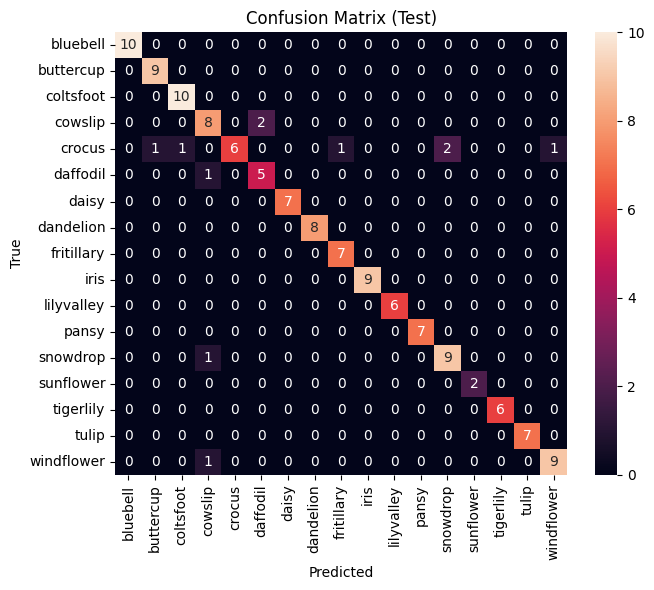

              precision    recall  f1-score   support

    bluebell     1.0000    1.0000    1.0000        10
   buttercup     0.9000    1.0000    0.9474         9
   coltsfoot     0.9091    1.0000    0.9524        10
     cowslip     0.7273    0.8000    0.7619        10
      crocus     1.0000    0.5000    0.6667        12
    daffodil     0.7143    0.8333    0.7692         6
       daisy     1.0000    1.0000    1.0000         7
   dandelion     1.0000    1.0000    1.0000         8
  fritillary     0.8750    1.0000    0.9333         7
        iris     1.0000    1.0000    1.0000         9
  lilyvalley     1.0000    1.0000    1.0000         6
       pansy     1.0000    1.0000    1.0000         7
    snowdrop     0.8182    0.9000    0.8571        10
   sunflower     1.0000    1.0000    1.0000         2
   tigerlily     1.0000    1.0000    1.0000         6
       tulip     1.0000    1.0000    1.0000         7
  windflower     0.9000    0.9000    0.9000        10

    accuracy              

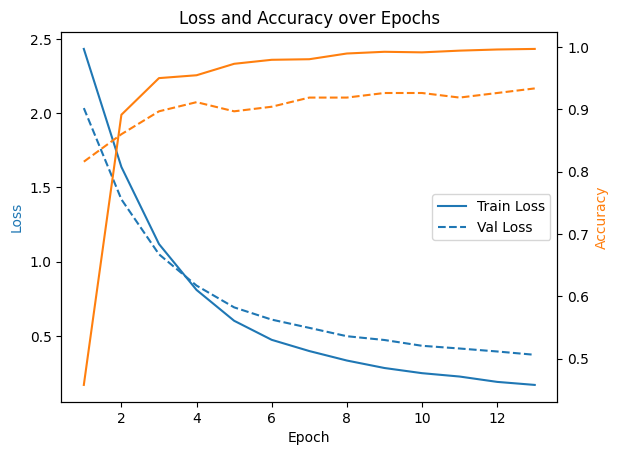

In [5]:
model, results = train_feature_extraction_classifier(
    "../data/flowers17",
    backbone="resnet50",
    save_path="resnet50_features_flowers17.pth",
    lr=1e-3,
    num_workers=0
)

In [ ]:
model, results = train_feature_extraction_classifier(
    "../data/caltech101",
    backbone="inception_v3",
    save_path="inceptionv3_features_caltech101.pth",
    lr=1e-3,
    num_workers=0
)

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /home/ryan/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


: 